In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

plt.rcParams['figure.dpi'] = 150

In [ ]:
#Veriyi İnceleme

df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")

print(f"Veri seti boyutları: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"\nSütun isimleri:\n \n{', '.join(df.columns.tolist())}")
print("\n")
print(f"\nVeri seti başlıkları: ")
print("\n")
display(df.head())
print("\n")
print(f"\nVeri seti istatistikleri: ")
print("\n")
display(df.describe())
print(f"\nVeri seti eksik değerleri: \n \n{df.isnull().sum()}")


Veri seti boyutları: 253680 satır, 22 sütun

Sütun isimleri:
 
Diabetes_012, HighBP, HighChol, CholCheck, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, AnyHealthcare, NoDocbcCost, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income



Veri seti başlıkları: 




,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0





Veri seti istatistikleri: 




,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,0.056197,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,0.230302,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000



Veri seti eksik değerleri: 
 
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [ ]:
#Özellik ve Hedef Ayırma
#Smoker sütunu hedef seçildi.

X = df.drop("Smoker", axis=1)
y = df["Smoker"]

print(f"Özellik Matrisi / X: {X.shape}")
print(f"Hedef vektör / y:  {y.shape}")
print(f"\nÖzellikler:  {X.columns.tolist()}")

Özellik Matrisi / X: (253680, 21)
Hedef vektör / y:  (253680,)

Özellikler:  ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [ ]:
#Eğitim ve Test Ayrımı

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

print(f"Eğitim tarafında {X_train.shape[0]} tane örnek")
print(f"Test tarafında {X_test.shape[1]} tane örnek")

print(f"\nEğitim veri seti dağılımı: \n{y_train.value_counts().to_string()}")
print(f"\nTest veri seti dağılımı: \n{y_test.value_counts().to_string()}")



Eğitim tarafında 202944 tane örnek
Test tarafında 21 tane örnek

Eğitim veri seti dağılımı: 
Smoker
0.0    113006
1.0     89938

Test veri seti dağılımı: 
Smoker
0.0    28251
1.0    22485


In [ ]:
#Standardizasyon (Ölçeklendirme)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Özellikleri standardize edersek: (mean=0, std=1)")
print(f"\n Eğitim setinin ilk satılarının ölçeklendirilmiş hali: ")
print(np.round(X_train_scaled[0], 5))

Özellikleri standardize edersek: (mean=0, std=1)

 Eğitim setinin ilk satılarının ölçeklendirilmiş hali: 
[-0.42391 -0.86699  1.16569  0.19761 -0.36013 -0.20543 -0.32181  0.56646
  0.75903  0.48178 -0.24419  0.22726 -0.30369 -0.47803  0.10971 -0.25616
 -0.44935 -0.88591 -1.97397  0.96348  0.93947]


In [ ]:
#Lojistik Regresyon Modeli Eğitimi

model = LogisticRegression(penalty = 'l2', C=1.0, solver = 'lbfgs', max_iter = 1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Model katsayıları

print(f"Kesişim (bias - β₀): {model.intercept_[0]:.4f}")
print(f"\nKatsayılar (β₁ ... βₙ):")
coef_df = pd.DataFrame({
    'Özellik': X.columns,
    'Katsayı': model.coef_[0],
    '|Katsayı|': np.abs(model.coef_[0])
}).sort_values('|Katsayı|', ascending=False)
display(coef_df)

Kesişim (bias - β₀): -0.2400

Katsayılar (β₁ ... βₙ):


,Özellik,Katsayı,|Katsayı|
10,HvyAlcoholConsump,0.233776,0.233776
19,Education,-0.228453,0.228453
17,Sex,0.228403,0.228403
18,Age,0.198994,0.198994
13,GenHlth,0.133140,0.133140
14,MentHlth,0.112542,0.112542
8,Fruits,-0.102818,0.102818
6,HeartDiseaseorAttack,0.087641,0.087641
2,HighChol,0.063538,0.063538
4,BMI,-0.063538,0.063538


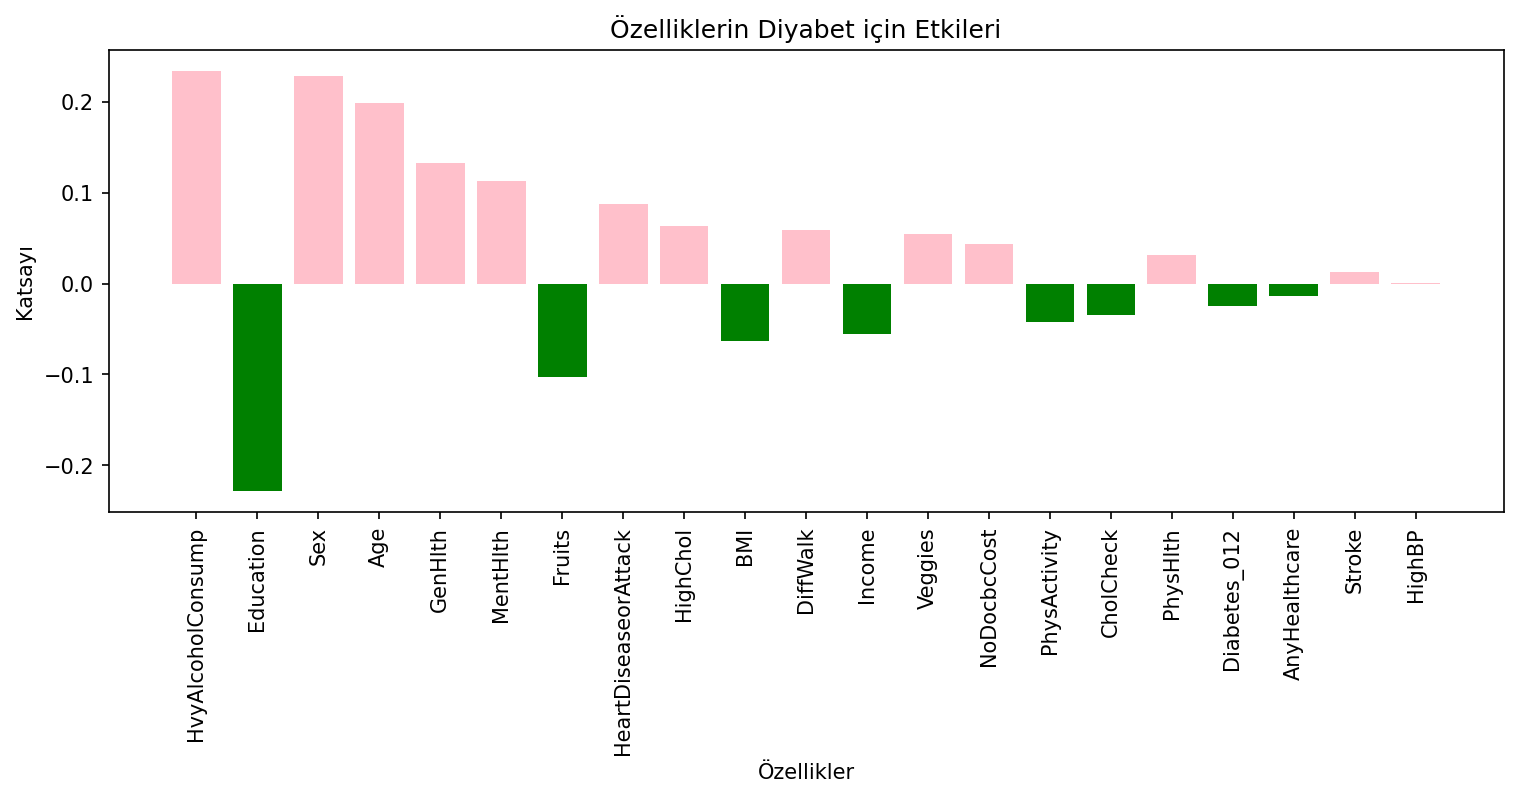

In [ ]:
#Özelliklerin Diyabet için önem sırası

plt.figure(figsize=(12,4))
colors = ['pink' if c > 0 else 'green' for c in coef_df['Katsayı']]
plt.bar(coef_df['Özellik'], coef_df['Katsayı'], color=colors)
plt.xlabel('Özellikler')
plt.ylabel('Katsayı')
plt.title('Özelliklerin Diyabet için Etkileri')
plt.xticks(rotation=90)
plt.show()


In [ ]:
#Modeli Değerlendirelim

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("Model Performansı")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC_ROC: {roc_auc:.4f}")

Model Performansı
Accuracy: 0.6293
Precision: 0.6116
Recall: 0.4478
F1 Score: 0.5170
AUC_ROC: 0.6673


In [ ]:
#Karmaşıklı Matrisini görelim

cm = confusion_matrix(y_test,y_pred)

print("   Karmaşıklık Matrisi")
print(f"\nTahmin:                   0            1")
print(f"Gerçek: 0 iken         {cm[0,0]:3d}(TN)    {cm[0,1]:3d}(FP)")
print(f"Gerçek: 1 iken         {cm[1,0]:3d}(FN)    {cm[1,1]:3d}(TP)")

print("\n----------------------------------------------------------------")

print("\n                Sınıflandırma Raporu")
print("\n")
print(classification_report(y_test, y_pred, target_names=["Sigara +", "Sigara -"]))

   Karmaşıklık Matrisi

Tahmin:                   0            1
Gerçek: 0 iken         21857(TN)    6394(FP)
Gerçek: 1 iken         12416(FN)    10069(TP)

----------------------------------------------------------------

                Sınıflandırma Raporu


              precision    recall  f1-score   support

    Sigara +       0.64      0.77      0.70     28251
    Sigara -       0.61      0.45      0.52     22485

    accuracy                           0.63     50736
   macro avg       0.62      0.61      0.61     50736
weighted avg       0.63      0.63      0.62     50736



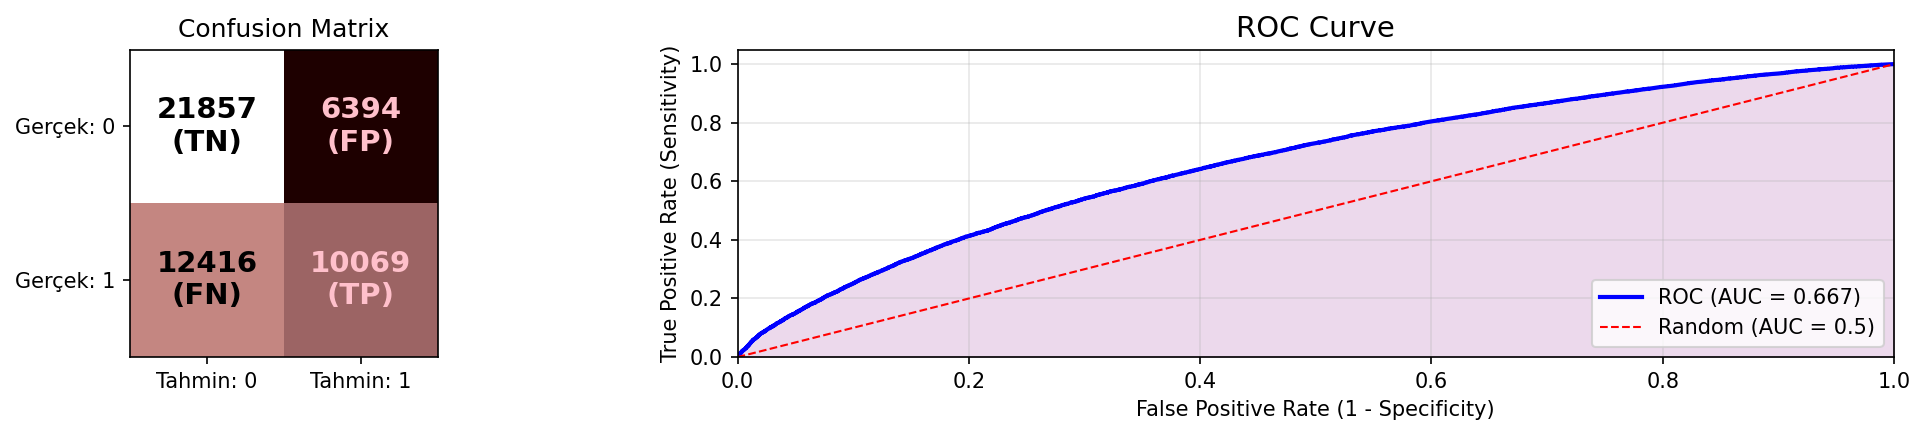

In [ ]:
#Karmaşıklık Matrisini Görselleştirelim

fig, ax = plt.subplots(1, 2, figsize=(15,3))

#Confusion Matrix Heatmap Çıkarılıyor

im = ax[0].imshow(cm, cmap = 'pink')
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['Tahmin: 0', 'Tahmin: 1'])
ax[0].set_yticklabels(['Gerçek: 0', 'Gerçek: 1'])
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, f'{cm[i, j]}\n({"TP" if i==1 and j==1 else "TN" if i==0 and j==0 else "FP" if i==0 and j==1 else "FN"})',
                 ha='center', va='center', fontsize=14, fontweight='bold',
                 color='black' if cm[i, j] > cm.max()/2 else 'pink')
ax[0].set_title('Confusion Matrix', fontsize=12)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
ax[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC = {roc_auc:.3f})')
ax[1].plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
ax[1].fill_between(fpr, tpr, alpha=0.15, color='purple')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('False Positive Rate (1 - Specificity)')
ax[1].set_ylabel('True Positive Rate (Sensitivity)')
ax[1].set_title('ROC Curve', fontsize=14)
ax[1].legend(loc='lower right')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Örnek Tahmin

sample = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample)
sample_proba = model.predict_proba(sample_scaled)[0, 1]
sample_pred = model.predict(sample_scaled)[0]

print("Örnek hasta verisi:")
display(sample)
print(f"\nHastalık olasılığı: {sample_proba:.4f} ({sample_proba*100:.1f}%)")
print(f"Tahmin: {sample_pred} ({'Sigara +' if sample_pred == 1 else 'Sigara -'})")
print(f"Gerçek: {y_test.iloc[0]}")

Örnek hasta verisi:


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
93167,0.0,1.0,1.0,1.0,31.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,10.0,5.0,7.0



Hastalık olasılığı: 0.5103 (51.0%)
Tahmin: 1.0 (Sigara +)
Gerçek: 1.0
